In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from scipy.optimize import curve_fit

In [2]:
folder = r"C:\Users\au617810\OneDrive - Aarhus universitet\O-drive - Jeppe\QTLab\AMO test rings"

files = os.listdir(folder)

data_frames = []

wav_start = []
wav_end = []
sweep_speed = []
ring_waveguide = []

for file in files:
    if file.endswith('.csv'):
        data = pd.read_csv(os.path.join(folder, file),delimiter=',',skiprows=11)
        data_frames.append((file, data))

        wav_start.append(int(file[5:9]))
        wav_end.append(int(file[10:14]))
        sweep_speed.append(int(file[17:20].replace('nm','').replace('n','')))
        ring_waveguide.append(file[0:4])
        
        

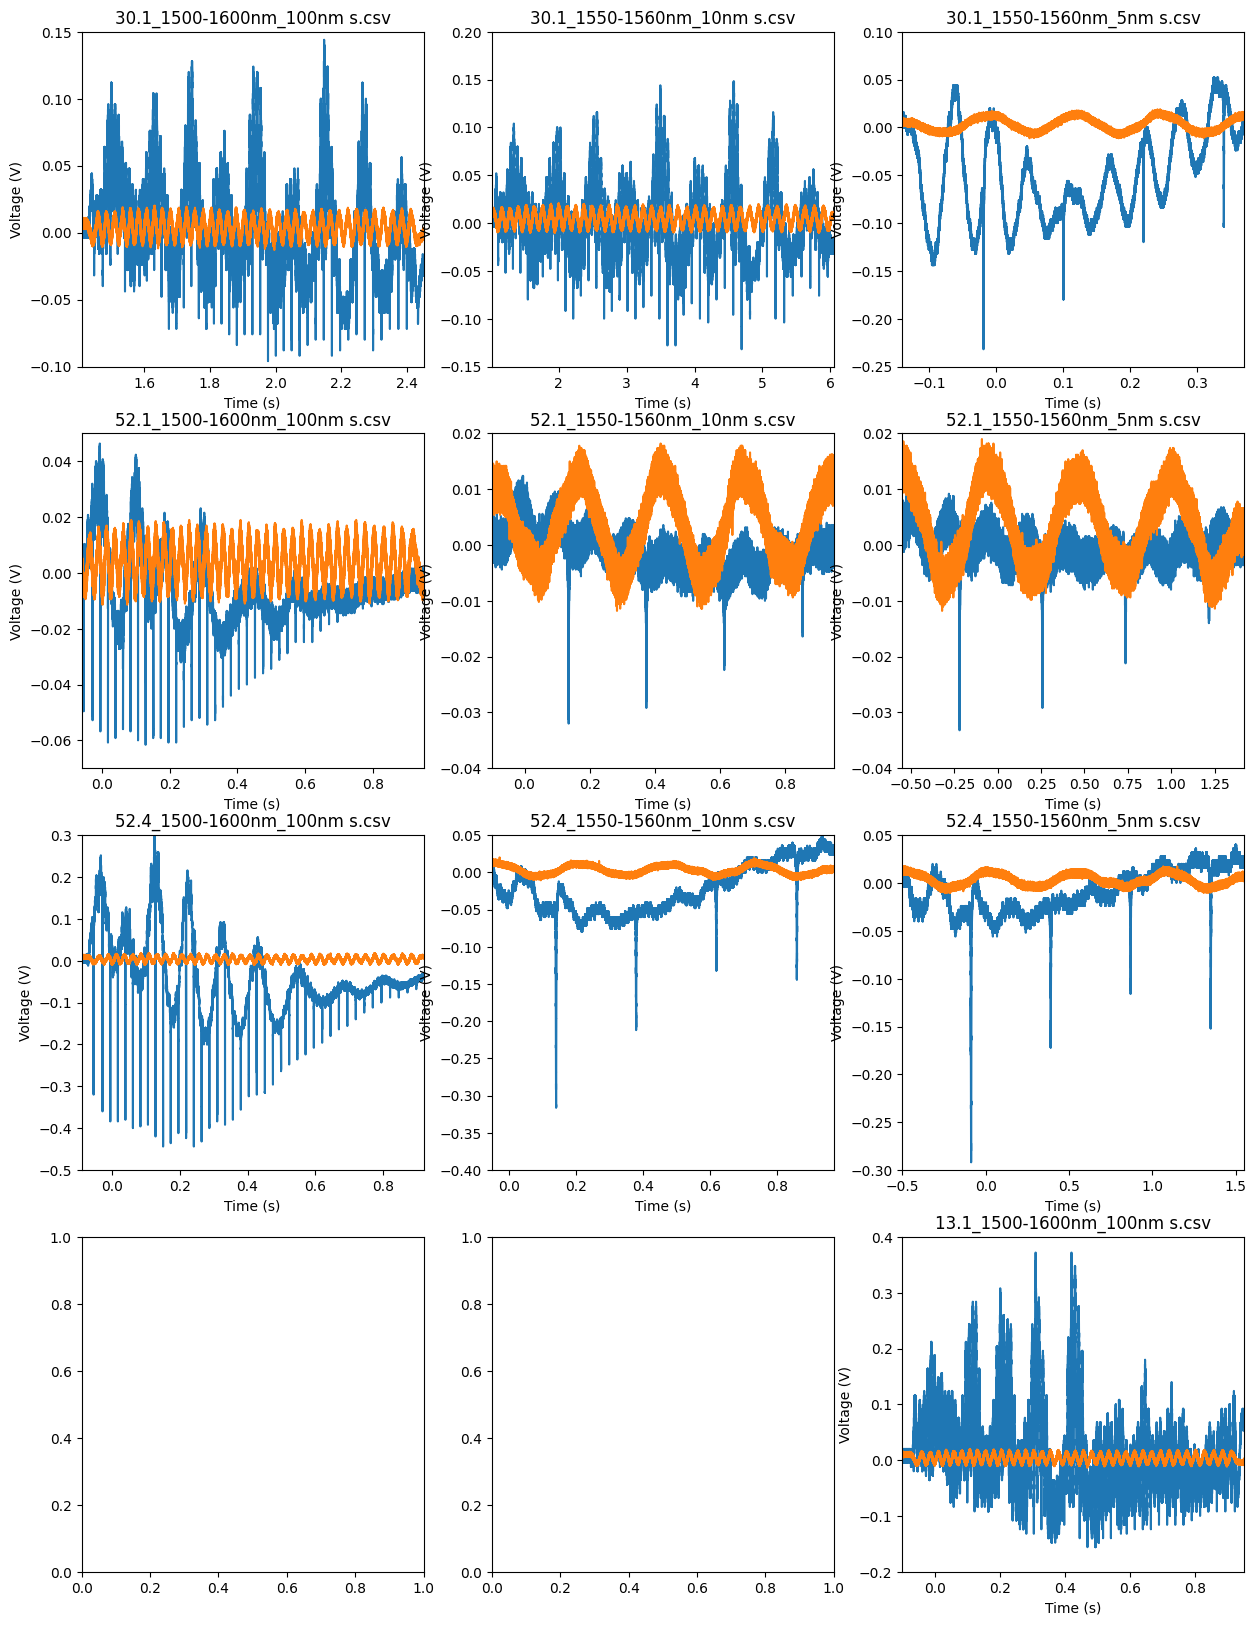

In [3]:
i=0
ax, fig = plt.subplots(4,3, figsize=(15,20))


x_start=[-0.1,
         1.41,1.02,-0.14,
         -0.06,-0.1,-0.55,
         -0.09,-0.05,-0.5]

x_end=[0.95,
       2.45,6.05,0.37,
       0.95,0.95,1.42,
       0.92,0.97,1.55]

y_start=[-0.2,
         -0.1,-0.15,-0.25,
         -0.07,-0.04,-0.04,
         -0.5,-0.4,-0.3]

y_end=[0.4,
       0.15,0.2,0.1,
       0.05,0.02,0.02,
       0.3,0.05,0.05]



for [file,df] in data_frames:

    axis = ax.axes[i-1]
    axis.plot(df['Second'], df['Volt'], label='Signal')
    axis.plot(df['Second'], df['Volt.1'], label='Reference')

    axis.set_title(file)
    axis.set_xlabel('Time (s)')
    axis.set_ylabel('Voltage (V)')

    axis.set_xlim(x_start[i], x_end[i])
    axis.set_ylim(y_start[i], y_end[i])

    i+=1


In [4]:
def mzi_fit(wavelength, amp, delay_length, phase, offset):

    n = 1.468 #effective refractive index at 1550nm

    OPD = n * delay_length #optical path difference

    return amp * np.sin(np.pi * OPD/wavelength + phase)**2 + offset


def time_to_wavelength(time, wav_start, wav_end, sweep_time_start, sweep_time_end):
    return wav_start + (wav_end - wav_start) * ( (time-sweep_time_start) / (sweep_time_end - sweep_time_start))  #Assuming linear sweep

def time_to_wavelength_sweep_speed(time, wav_start, sweep_time_start, sweep_speed):
    return wav_start + sweep_speed * (time-sweep_time_start)  #Assuming linear sweep, and instantly jumping to sweep speed


In [5]:
# wav_end[2] = 1600 #To fix mistake in filename

# wav_end[3] = 1600 #To fix mistake in filename


index_start = []
index_end = []

seconds = []
ring_volts = []
mzi_volts = []


wavelengths_1 = []
wavelengths_2 = []

sweep_speed_calc = []


j = 0

for [file,df] in data_frames:
    
    x_val = df['Second']

    x_range  = x_val[(x_val>x_start[j]) & (x_val<x_end[j])]

    i_start = np.where( x_val == np.min(x_range) )[0][0]
    i_end = np.where( x_val == np.max(x_range) )[0][0]

    index_start.append(i_start)
    index_end.append(i_end)

    seconds.append(x_range)
    volt = df['Volt.1'][i_start:i_end+1]
    ring_volts.append( df['Volt'][i_start:i_end+1] )
    mzi_volts.append(volt)

    wavelengths_1.append( time_to_wavelength(x_range, wav_start[j], wav_end[j], x_val[i_start], x_val[i_end]) )

    wavelengths_2.append( time_to_wavelength_sweep_speed(x_range, wav_start[j], x_val[i_start], sweep_speed[j]) )

    sweep_speed_calc.append( [(wav_end[j]-wav_start[j]) / ( x_val[i_end] - x_val[i_start] ), file] )


    # plt.figure(j)
    # plt.plot(seconds[j]-seconds[j][i_start],wavelengths_1[j],'.',label='Calculated from wav start and end')
    # plt.plot(seconds[j]-seconds[j][i_start],wavelengths_2[j],'.',label='Calculated from sweep speed')

    # plt.legend()
    # plt.grid()

    j+=1

print(sweep_speed,sweep_speed_calc)

[100, 100, 10, 5, 100, 10, 5, 100, 10, 5] [[95.23827664433647, '13.1_1500-1600nm_100nm s.csv'], [96.15421597775376, '30.1_1500-1600nm_100nm s.csv'], [1.9880794754651112, '30.1_1550-1560nm_10nm s.csv'], [19.607920031058942, '30.1_1550-1560nm_5nm s.csv'], [99.01009704969714, '52.1_1500-1600nm_100nm s.csv'], [9.523827664433647, '52.1_1550-1560nm_10nm s.csv'], [5.076152438888201, '52.1_1550-1560nm_5nm s.csv'], [99.01009704969714, '52.4_1500-1600nm_100nm s.csv'], [9.80394079204077, '52.4_1550-1560nm_10nm s.csv'], [4.8780582986503385, '52.4_1550-1560nm_5nm s.csv']]


In [6]:
popts = []
covs = []

amps = []

L_guess = 6.65e-04 # in meters

i = 0
for [_,df] in data_frames:

    wav = wavelengths_1[i]*1e-9 #Convert to meters

    mzi_volt  = mzi_volts[i]

    max_volt = np.max(mzi_volt)
    min_volt = np.min(mzi_volt)

    amp_volt = (max_volt - min_volt)
    amps.append(amp_volt)

    popt, cov = curve_fit(mzi_fit,wav,mzi_volt,p0 = [amp_volt, L_guess, np.pi/2, min_volt],bounds=([amp_volt*0.7,L_guess/2,-np.pi,min_volt],[amp_volt*1.3,L_guess*2,np.pi,min_volt+amp_volt/2]) )
                                              
    popts.append(popt)
    covs.append(cov)

    i+=1

In [7]:
amps

[0.033600000000000005,
 0.0332,
 0.0308,
 0.0304,
 0.0304,
 0.03,
 0.0308,
 0.0288,
 0.0308,
 0.0284]

In [8]:
popts

[array([ 2.35202193e-02,  6.67098226e-04, -3.13969158e+00, -8.04573970e-03]),
 array([ 2.32401494e-02,  6.65485078e-04,  1.01878505e+00, -8.11336709e-03]),
 array([ 2.15696290e-02,  6.66659229e-04, -3.13997259e+00, -6.31426337e-03]),
 array([ 2.12846540e-02,  6.65389464e-04,  1.12575814e+00, -7.70885537e-03]),
 array([ 2.20938766e-02,  6.66625472e-04, -3.12017432e+00, -7.82483279e-03]),
 array([ 2.10001451e-02,  6.65492577e-04,  7.36466304e-01, -6.93792151e-03]),
 array([ 2.15601597e-02,  6.65478980e-04,  1.02342227e+00, -7.59423161e-03]),
 array([ 2.01600000e-02,  6.66245093e-04, -3.14159265e+00, -6.25913161e-03]),
 array([ 0.02156   ,  0.00066563,  0.58783208, -0.00763249]),
 array([ 1.98801659e-02,  6.65483156e-04,  1.01171146e+00, -6.71530436e-03])]

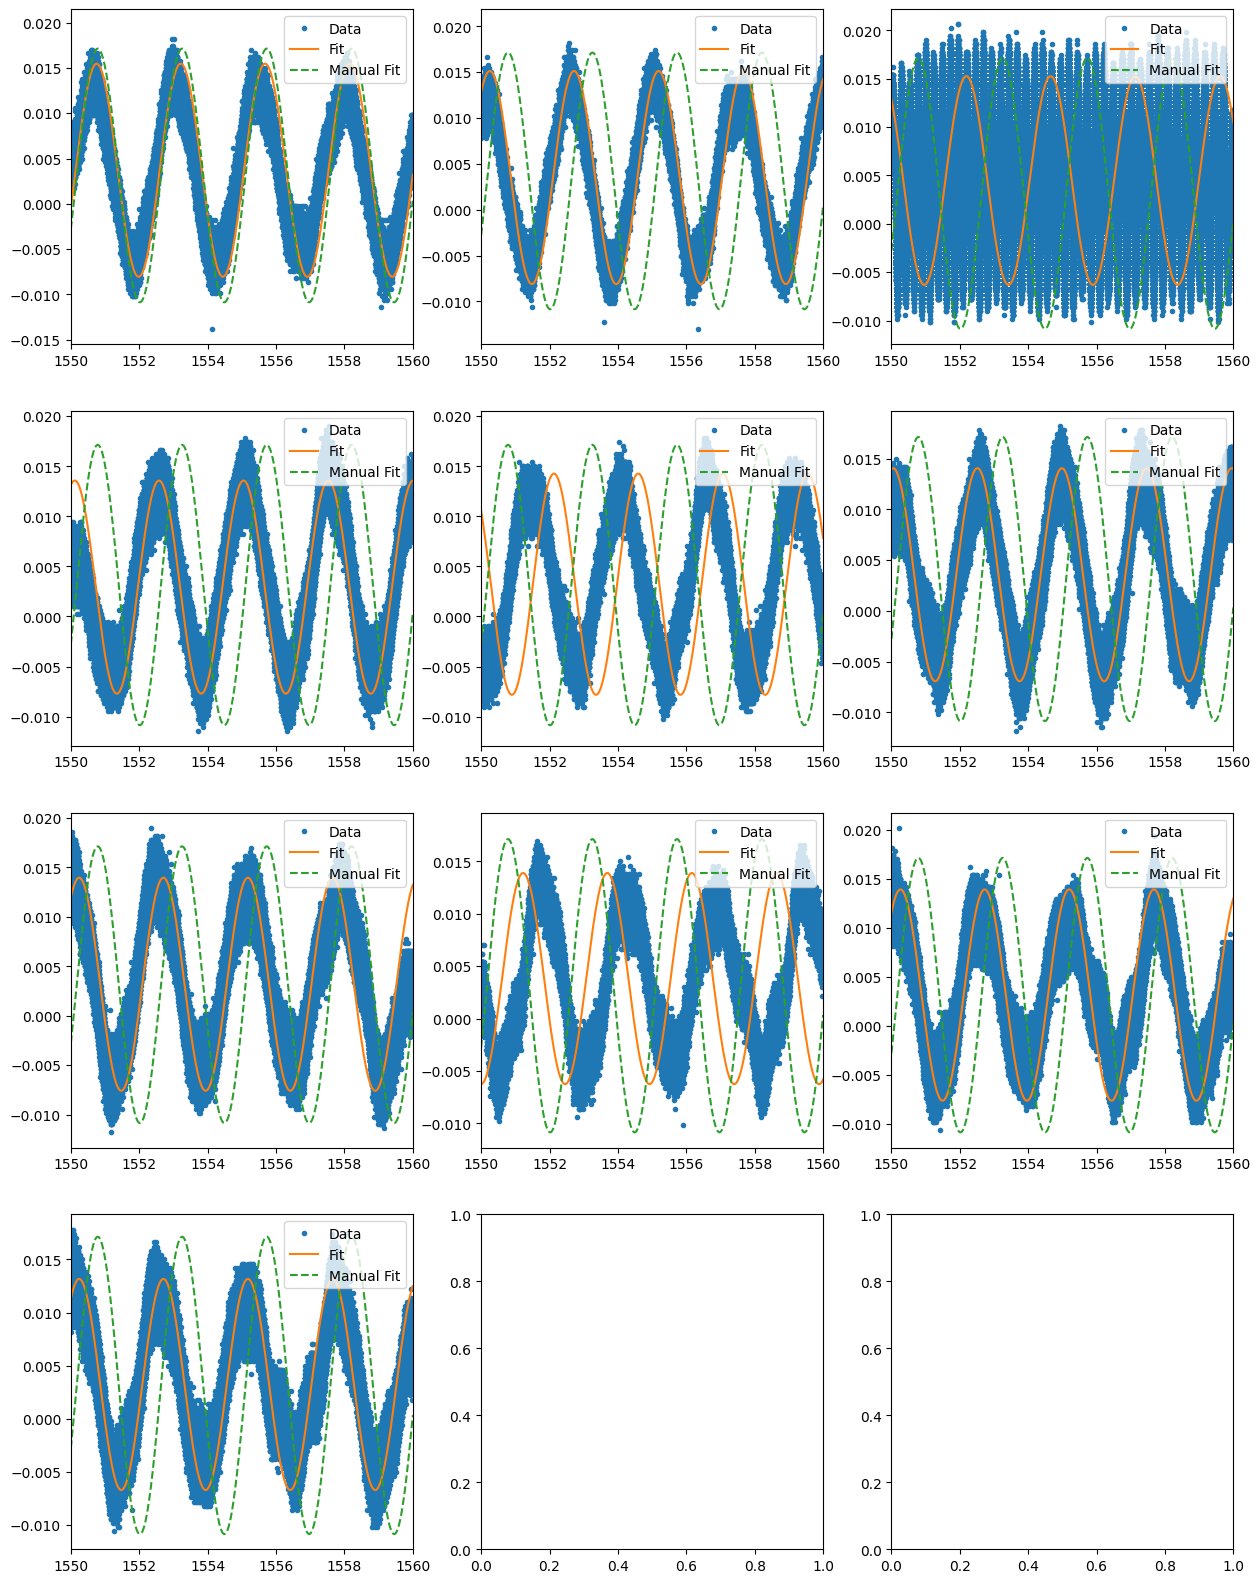

In [9]:

ax, fig = plt.subplots(4,3, figsize=(15,20))

for k in range(len(mzi_volts)):
    axis = ax.axes[k]

    axis.plot(wavelengths_1[k], mzi_volts[k],'.', label='Data')
    fit = mzi_fit(np.array(wavelengths_1[k])*1e-9, *popts[k])

    axis.plot(np.array(wavelengths_1[k]), fit, '-', label='Fit')

    fit_man = mzi_fit(np.array(wavelengths_1[k])*1e-9, 2.8e-2,  6.65e-04, -np.pi, -10.86241801e-03)

    axis.plot(np.array(wavelengths_1[k]), fit_man, '--', label='Manual Fit')

    axis.legend(loc='upper right')
    axis.set_xlim([1550,1560])

In [10]:
avg_mzi_volts = [np.average(mzi_volt) for mzi_volt in mzi_volts]
ptp_mzi_volts = [np.max(mzi_volt)-np.min(mzi_volt) for mzi_volt in mzi_volts]

ER_mzi_volts = [(np.min(mzi_volt)/np.max(mzi_volt)) for mzi_volt in mzi_volts]

avg_mzi_volts, ptp_mzi_volts, ER_mzi_volts

([0.003704335416794874,
  0.0035074977873015153,
  0.004557836894810526,
  0.003033025959389136,
  0.003666708663961052,
  0.0036665860310776477,
  0.0032761378260153565,
  0.003854801096832468,
  0.003233927148003478,
  0.0033079490347924247],
 [0.033600000000000005,
  0.0332,
  0.0308,
  0.0304,
  0.0304,
  0.03,
  0.0308,
  0.0288,
  0.0308,
  0.0284],
 [-0.6969696969696969,
  -0.6435643564356436,
  -0.49514563106796117,
  -0.6000000000000001,
  -0.6000000000000001,
  -0.6483516483516483,
  -0.6210526315789474,
  -0.5824175824175823,
  -0.5247524752475248,
  -0.5955056179775281])

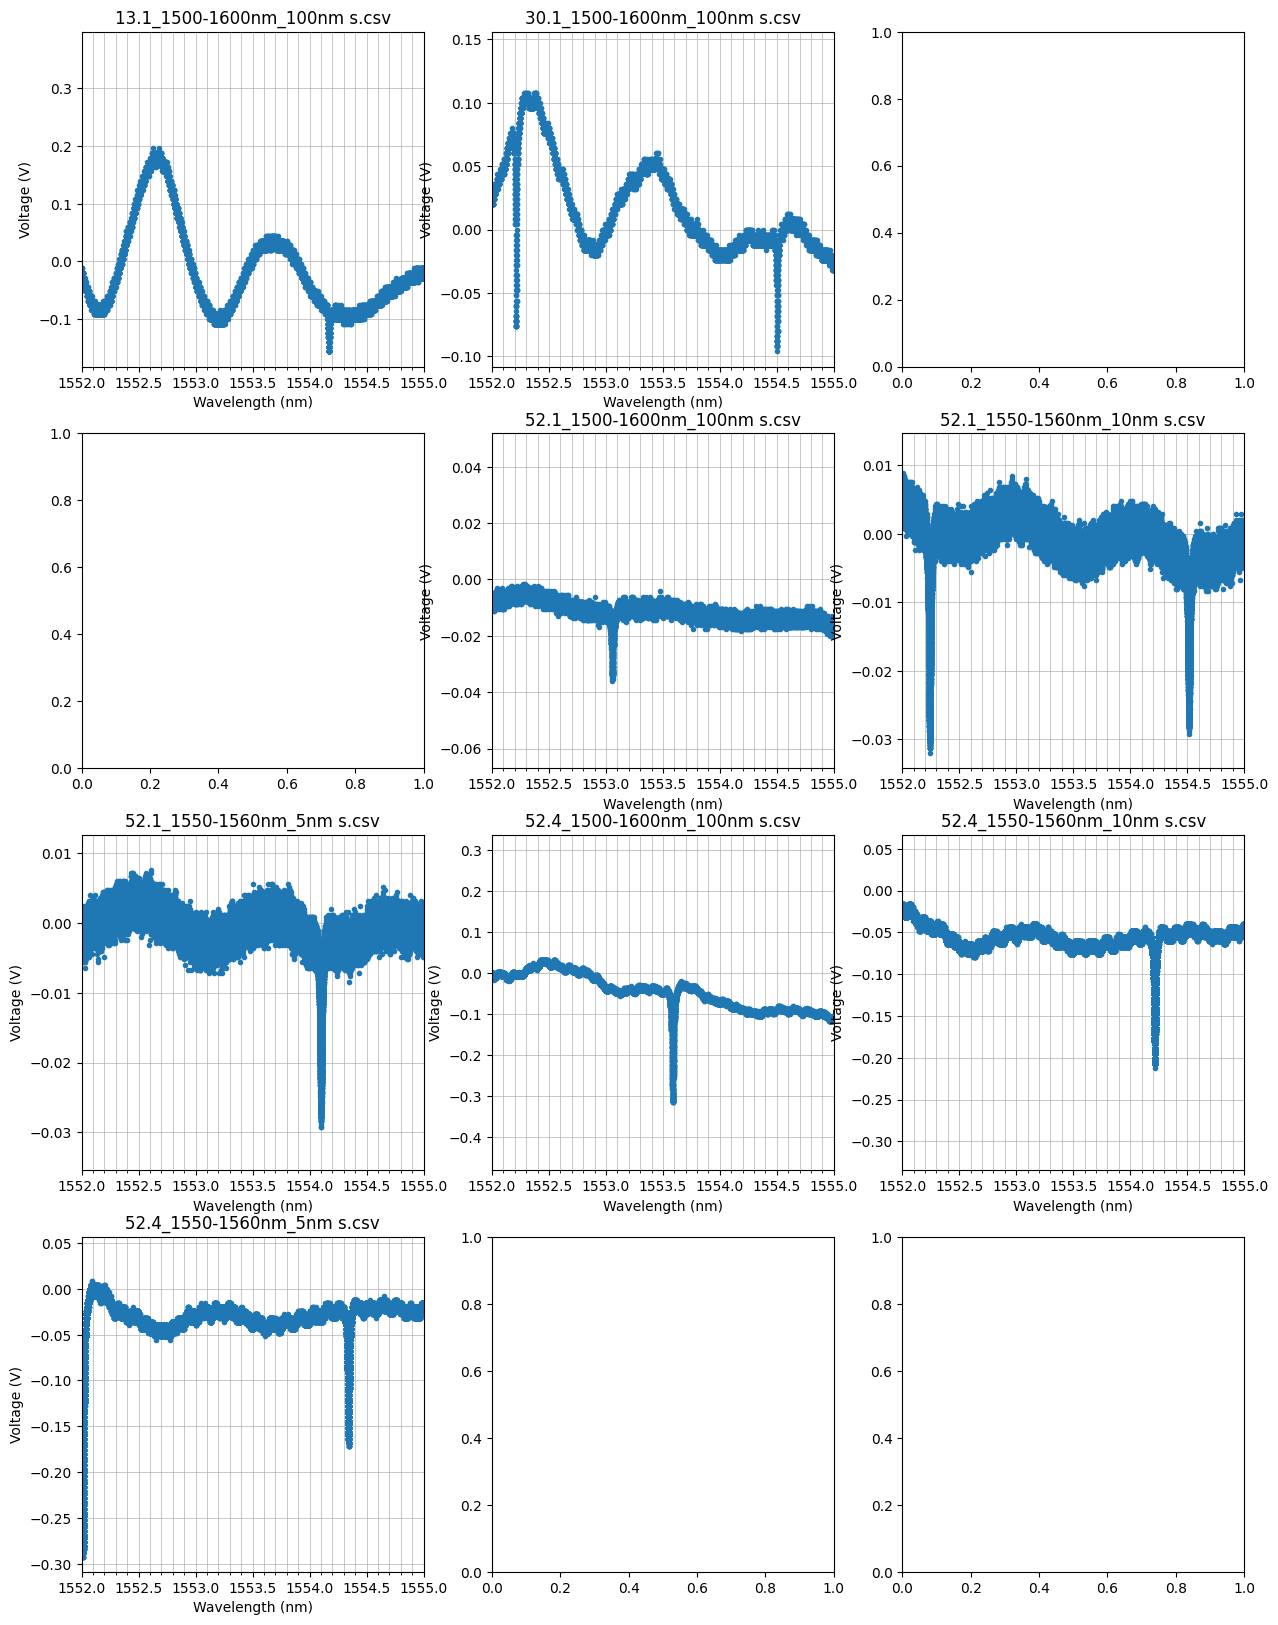

In [18]:
ax, fig = plt.subplots(4,3, figsize=(15,20))

for k in range(len(mzi_volts)):
    if k not in [2,3]:
        axis = ax.axes[k]

        axis.plot(wavelengths_1[k], ring_volts[k],'.', label='Data')
        axis.set_title(files[k])
        axis.set_xlabel('Wavelength (nm)')
        axis.set_ylabel('Voltage (V)')
        axis.set_xlim([1552,1555])
        axis.grid('on', which='both', axis='both', linestyle='-', linewidth=0.5)
        axis.xaxis.set_minor_locator(plt.MultipleLocator(0.1))